YOLOv3 모델을 사용하기 위해서는 추가적인 YOLO 관련 pip 패키지가 필요 없음  
YOLOv3 모델은 OpenCV의 cv2.dnn 모듈을 사용해 로드하고 실행할 수 있기 때문에,   
OpenCV(opencv-python-headless 또는 opencv-python)만 설치하면 충분

YOLO 파일(yolov3.weights, yolov3.cfg, coco.names)을 다운로드하여 직접 경로를 설정하고 사용하면 됨

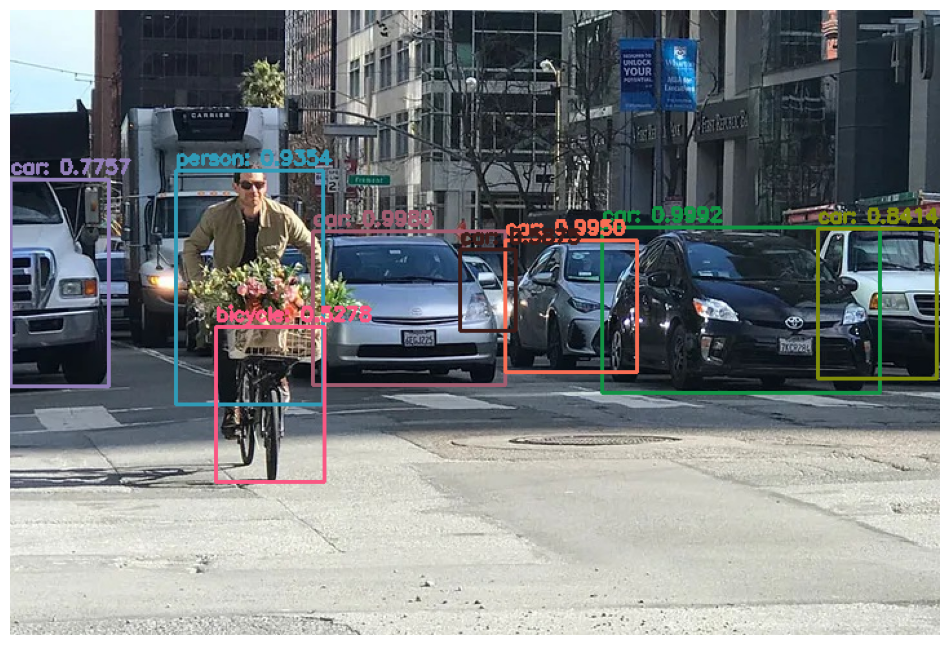

True

In [1]:
# ============================================================
# YOLOv3로 사진 속 물체 찾기 (객체 탐지, 추론만 수행 / 학습 X)
#
# 전체 흐름
#  1) 이름표(coco.names)와 미리 학습된 모델(cfg + weights)을 불러온다
#  2) 사진을 읽어서 YOLO가 먹을 수 있는 형태(blob)로 바꾼다
#  3) 모델에 넣어서 "후보 박스" 수천 개를 받는다
#  4) 확신이 낮은 후보를 버린다 (confidence > 0.5)
#  5) 같은 물체에 겹친 박스를 하나만 남긴다 (NMS, 비최대 억제)
#  6) 남은 박스와 이름을 사진 위에 그려서 보여주고 저장한다
# ============================================================
import cv2                        # OpenCV: 이미지 읽기/그리기 + YOLO 모델 실행(cv2.dnn)
import numpy as np                # 배열(숫자 묶음) 계산용
import matplotlib.pyplot as plt   # 결과 이미지를 노트북 화면에 보여주기 위함

# ---------- 1) 모델 파일 경로 설정 ----------
# YOLOv3 설정 파일, 가중치 파일, 클래스 이름 파일 경로 설정
weights_path = 'yolov3.weights'   # 미리 학습된 가중치(숫자들). 모델의 "학습된 지식" 자체. 약 248MB
cfg_path = 'yolov3.cfg'           # 모델 구조 설계도 (어떤 층을 어떻게 쌓았는지 적힌 텍스트 파일)
names_path = 'coco.names'         # 모델이 구분할 수 있는 80가지 물체 이름 목록 (사람, 개, 자동차 ...)

# 클래스 이름 로드
with open(names_path, 'r') as f:                     # 이름 파일을 읽기 모드('r')로 연다. with: 다 쓰면 자동으로 닫아줌
    class_names = f.read().strip().split('\n')       # 전체 텍스트를 읽고 → 앞뒤 공백 제거 → 줄바꿈 기준으로 잘라 리스트로 만든다
                                                     # 결과: ['person', 'bicycle', 'car', ...] (인덱스 0~79)

# YOLOv3 네트워크 로드
net = cv2.dnn.readNetFromDarknet(cfg_path, weights_path)   # Darknet(YOLO를 만든 프레임워크) 형식의 모델을 OpenCV로 불러온다
                                                            # cfg(구조) + weights(학습된 값)를 합쳐서 실행 가능한 net 객체가 됨

# ---------- 2) 이미지 로드 및 전처리 ----------
img_path = '../dataset/path_to_your_image.jpg'   # 탐지할 사진 경로 (이 노트북이 있는 폴더 기준 상대경로, ../ = 한 단계 위)
img = cv2.imread(img_path)                       # 사진을 숫자 배열로 읽는다. 색 순서가 BGR(파랑-초록-빨강)임에 주의!
                                                 # 경로가 틀리면 에러 없이 None이 돌아와서 다음 줄에서 터진다
height, width = img.shape[:2]                    # shape = (세로, 가로, 채널수) → 앞의 두 개만 가져옴. 박스 좌표를 원래 크기로 되돌릴 때 필요

# YOLO에 맞게 이미지 전처리
blob = cv2.dnn.blobFromImage(img,                # blob = 딥러닝 모델 입력 형태로 바꾼 이미지
                             1/255.0,            # 픽셀 값(0~255)을 0~1 사이로 줄임 (정규화)
                             (416, 416),         # 모델이 받는 크기로 리사이즈 (416x416). 가로세로 비율은 무시하고 찌그러뜨려 맞춤
                             swapRB=True,        # BGR → RGB로 순서 교체 (YOLO는 RGB로 학습됨)
                             crop=False)         # 잘라내지 않고 전체를 줄여서 사용
net.setInput(blob)                               # 전처리한 이미지를 모델의 입력으로 지정

# ---------- 3) 모델 실행 ----------
# YOLO 네트워크에서 출력을 가져옴
layer_names = net.getLayerNames()                # 모델의 모든 층 이름 목록 (수백 개)
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]
                                                 # getUnconnectedOutLayers() = "뒤에 연결된 층이 없는 층" = 결과를 내보내는 출력층의 번호
                                                 # 번호는 1부터 시작하고 파이썬 리스트는 0부터라서 i - 1 로 맞춘다
                                                 # YOLOv3는 큰/중간/작은 물체용 출력층이 3개 있다
outputs = net.forward(output_layers)             # 실제로 모델을 돌린다(순전파). 출력층 3개의 결과를 리스트로 받음
                                                 # 각 결과는 표 모양: 한 줄 = 후보 박스 하나
                                                 # 한 줄 구성 = [중심x, 중심y, 너비, 높이, 물체일 확률, 80개 클래스별 점수...]
                                                 # 좌표는 사진 크기에 대한 비율(0~1) / 후보는 총 10,647개 정도

# ---------- 4) 결과 처리: 확신 높은 후보만 고르기 ----------
# 결과 처리
boxes = []          # 통과한 후보들의 박스 좌표 [x, y, 너비, 높이]를 모을 리스트
confidences = []    # 각 박스의 확신도(확률)
class_ids = []      # 각 박스가 어떤 물체인지 (coco.names의 번호)

for output in outputs:                    # 출력층 3개를 하나씩 꺼낸다
    for detection in output:              # 그 안의 후보 박스를 한 줄씩 꺼낸다
        scores = detection[5:]            # 6번째 값부터 끝까지 = 80개 클래스(사람, 개, ...) 각각의 점수
        class_id = np.argmax(scores)      # 점수가 가장 큰 칸의 번호 = 이 박스가 가장 닮은 물체 번호
        confidence = scores[class_id]     # 그 최고 점수 = 이 박스에 대한 확신도
        if confidence > 0.5:              # 확신이 50%를 넘는 것만 통과 (낮추면 더 많이/엉터리도 잡히고, 높이면 확실한 것만 남음)
            box = detection[0:4] * np.array([width, height, width, height])
                                          # 앞 4개(중심x, 중심y, 너비, 높이)는 0~1 비율 → 원래 사진 크기를 곱해 실제 픽셀 값으로 변환
            (centerX, centerY, w, h) = box.astype("int")   # 소수를 정수로 바꿔서 4개 변수에 나눠 담는다
            x = int(centerX - (w / 2))    # YOLO는 "중심 좌표"를 주는데, 그리기엔 "왼쪽 위 모서리"가 필요 → 중심에서 너비의 절반을 뺀다
            y = int(centerY - (h / 2))    # 마찬가지로 중심에서 높이의 절반을 빼서 위쪽 모서리를 구한다
            boxes.append([x, y, int(w), int(h)])   # [왼쪽 위 x, 왼쪽 위 y, 너비, 높이] 로 저장
            confidences.append(float(confidence))  # 확신도 저장 (float로 바꾸는 이유: NMS 함수가 파이썬 숫자를 요구)
            class_ids.append(class_id)             # 물체 번호 저장

# ---------- 5) 겹친 박스 정리 ----------
# 비최대 억제 적용
indices = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)
                                          # NMS(Non-Maximum Suppression, 비최대 억제):
                                          #  같은 물체 하나에 후보 박스가 여러 개 겹쳐서 잡히는데, 그중 확신도가 가장 높은 것만 남기는 작업
                                          # 0.5 = 확신도 하한선 (이보다 낮은 건 버림)
                                          # 0.4 = 겹침 허용치(IoU). 두 박스가 40% 넘게 겹치면 같은 물체로 보고 확신도 낮은 쪽을 제거
                                          # 결과 indices = 살아남은 박스들의 번호

# ---------- 6) 박스 그리기 ----------
# 탐지된 객체의 바운딩 박스 그리기
if len(indices) > 0:                      # 살아남은 박스가 하나라도 있을 때만 그린다 (없으면 건너뜀)
    for i in indices.flatten():           # 번호 묶음을 1차원으로 펴서 하나씩 꺼낸다 (OpenCV 버전에 따라 모양이 달라서 flatten 사용)
        (x, y) = (boxes[i][0], boxes[i][1])   # i번 박스의 왼쪽 위 모서리 좌표
        (w, h) = (boxes[i][2], boxes[i][3])   # i번 박스의 너비와 높이
        color = [int(c) for c in np.random.randint(0, 255, size=3)]
                                          # 0~255 사이 난수 3개로 랜덤 색깔을 만든다 (실행할 때마다 색이 바뀜)
        cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)
                                          # 사진(img) 위에 사각형을 직접 그린다: (왼쪽 위) ~ (오른쪽 아래), 색, 선 두께 2
        text = "{}: {:.4f}".format(class_names[class_ids[i]], confidences[i])
                                          # 박스 위에 쓸 글자 만들기. 예) "dog: 0.9873"
                                          # class_ids[i] = 물체 번호 → class_names[...] 로 이름으로 변환, 확신도는 소수점 4자리까지
        cv2.putText(img, text, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
                                          # 글자를 사진 위에 쓴다: 글자, 위치(박스 왼쪽 위에서 5픽셀 위), 글꼴, 글자 크기 0.5, 색, 두께 2

# ---------- 7) 결과 보여주기/저장 ----------
# 결과 이미지 표시
plt.figure(figsize=(12, 12))                       # 12x12 인치의 큰 그림 영역을 만든다
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))   # OpenCV는 BGR, matplotlib는 RGB를 쓰기 때문에 색 순서를 바꿔서 보여줘야 색이 정상으로 나옴
plt.axis('off')                                    # 눈금/축 숫자를 숨김
plt.show()                                         # 화면에 출력

# 결과 이미지 저장
output_img_path = 'output_image.jpg'               # 저장할 파일 이름 (이 노트북이 있는 폴더에 생김)
cv2.imwrite(output_img_path, img)                  # 박스가 그려진 사진을 파일로 저장 (True/False를 돌려줘서 셀 아래에 True가 찍힘)

In [2]:
!pip install ultralytics

  Using cached opencv_python-5.0.0.93.tar.gz (81.8 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 12.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.0/17.0 MB 15.7 MB/s  0:00:01m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 876.6/876.6 kB 4.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 MB 12.1 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.8/150.8 MB 12.0 MB/s  0:00:12m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 45.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 56.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 31.1 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 13.8 MB/s  0:00:00
  Created wheel for opencv-python: filename=opencv_python-5.0.0.93-cp311-cp311-maco

In [3]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model = YOLO("yolov8n.pt") # yolov8s.pt, yolov8m.pt 등도 가능

img_path = "../dataset/path_to_your_image.jpg"

results = model(img_path)

results[0].show()

results[0].save(filename="output_image_v8.jpg")

for box in results[0].boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    print(f"Class: {model.names[cls]}, Confidence: {conf:.4f}")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/greenpianorabbit/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.

image 1/1 /Users/greenpianorabbit/Documents/Development/ict_innovation_sq_voice_ai/007_전이학습/../dataset/path_to_your_image.jpg: 448x640 1 person, 1 bicycle, 9 cars, 179.8ms
Speed: 63.0ms preprocess, 179.8ms inference, 4.0ms postprocess per image at shape (1, 3, 448, 640)
Class: car, Confidence: 0.8970
Class: car, Confidence: 0.8728
Class: car, Confidence: 0.8548
Class: person, Confidence: 0.8442
Class: car, Confidence: 0.7608
Class: car, Confidence: 0.7351
Class: bicycle, Confidence: 0.6919
Class: car, Confidence: 0.4523
Class: car, Confidence: 0.3680
Class: car, Confidence: 0.2802
Class: car, Confidence: 0.2503
